## Initial Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the gnomAD CSV file
filename = "gnomAD_v4.1.0_ENSG00000136689_2025_12_24_10_52_40.csv"
df = pd.read_csv(filename)

# Display basic info
print(f"Loaded {len(df)} variants")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())

Loaded 1025 variants
Shape: (1025, 72)

First few rows:
         gnomAD ID  Chromosome   Position        rsIDs Reference Alternate  \
0  2-113117944-C-A           2  113117944          NaN         C         A   
1  2-113117945-T-C           2  113117945          NaN         T         C   
2  2-113117947-T-C           2  113117947          NaN         T         C   
3  2-113117948-A-G           2  113117948  rs748164399         A         G   
4  2-113117949-T-C           2  113117949          NaN         T         C   

                         Source Filters - exomes Filters - genomes  \
0                 gnomAD Exomes             PASS               NaN   
1                 gnomAD Exomes             PASS               NaN   
2                 gnomAD Exomes             PASS               NaN   
3  gnomAD Exomes,gnomAD Genomes             PASS              PASS   
4                 gnomAD Exomes             PASS               NaN   

          Transcript  ... Homozygote Count Amish Hemiz


MUTATION TYPE ANALYSIS

Total number of variants: 1025

Total unique mutation types: 14

Mutation type counts:
VEP Annotation
intron_variant             444
missense_variant           266
synonymous_variant         119
5_prime_UTR_variant         67
3_prime_UTR_variant         59
splice_region_variant       27
frameshift_variant          13
stop_gained                  8
splice_donor_variant         6
start_lost                   6
inframe_deletion             4
splice_acceptor_variant      3
stop_lost                    2
stop_retained_variant        1
Name: count, dtype: int64


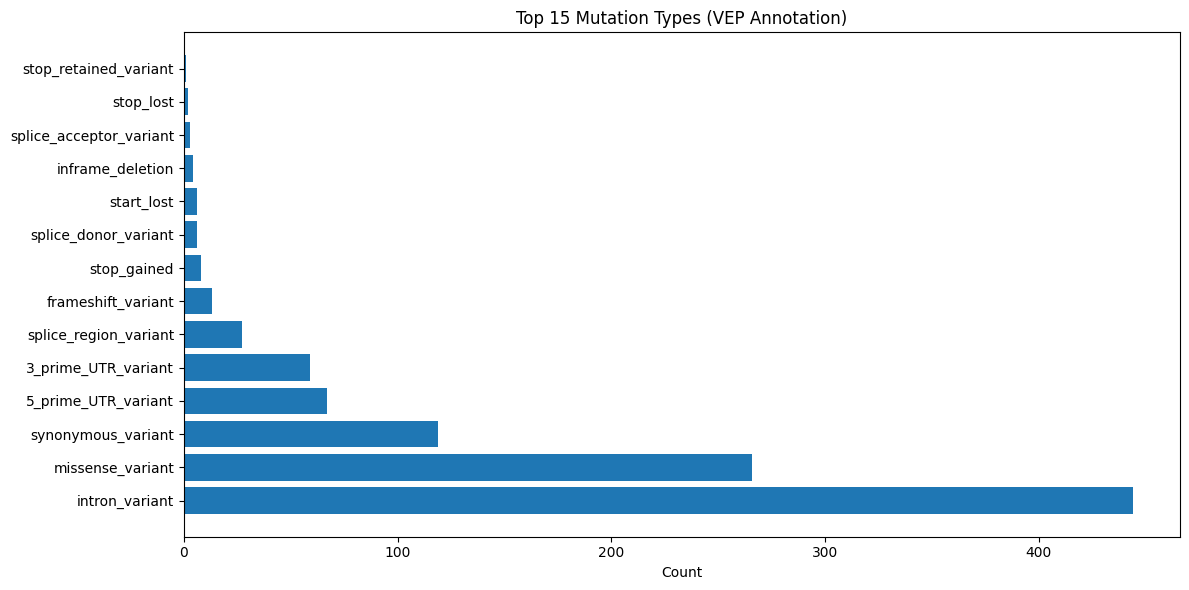

In [ ]:
# Evaluate mutation types from VEP Annotation
print("\n" + "="*60)
print("MUTATION TYPE ANALYSIS")
print("="*60)

print(f"\nTotal number of variants: {len(df['VEP Annotation'])}")

mutation_counts = df['VEP Annotation'].value_counts()
print(f"\nTotal unique mutation types: {len(mutation_counts)}")
print(f"\nMutation type counts:")
print(mutation_counts)

# Visualize top mutation types
plt.figure(figsize=(12, 6))
top_mutations = mutation_counts.head(15)
plt.barh(range(len(top_mutations)), top_mutations.values)
plt.yticks(range(len(top_mutations)), top_mutations.index)
plt.xlabel('Count')
plt.title('Top 15 Mutation Types (VEP Annotation)')
plt.tight_layout()
plt.show()

## Missense mutations

In [ ]:
# Filter for missense variants
print("\n" + "="*60)
print("MISSENSE VARIANT ANALYSIS")
print("="*60)

missense_df = df[df['VEP Annotation'] == 'missense_variant'].copy()
print(f"\nTotal missense variants: {len(missense_df)}")
print(f"Percentage of all variants: {len(missense_df)/len(df)*100:.2f}%")

print(f"\nFirst few missense mutations (HGVS Consequence):")
print(missense_df['HGVS Consequence'].head(10))

print(f"\nUnique missense mutations: {missense_df['HGVS Consequence'].nunique()}")


MISSENSE VARIANT ANALYSIS

Total missense variants: 266
Percentage of all variants: 25.95%

First few missense mutations (HGVS Consequence):
51     p.Ala2Ser
52     p.Ala2Thr
53     p.Leu3Ile
54     p.Leu3Ser
55     p.Ala4Pro
130    p.Asp5Glu
131    p.Leu6Val
133    p.Leu6Phe
134    p.Tyr7Cys
137    p.Glu9Lys
Name: HGVS Consequence, dtype: object

Unique missense mutations: 263


In [ ]:
def extract_substitution(hgvs):
    if pd.isna(hgvs):
        return None
    # Remove 'p.' prefix and extract amino acids
    hgvs = str(hgvs).replace('p.', '')
    # Find where numbers start
    import re
    match = re.match(r'([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})', hgvs)
    if match:
        from_aa = match.group(1)
        to_aa = match.group(3)
        return f"{from_aa}->{to_aa}"
    return None

missense_df['Substitution'] = missense_df['HGVS Consequence'].apply(extract_substitution)

substitution_counts = missense_df['Substitution'].value_counts()
print(f"\nTop 10 most common substitutions:")
print(substitution_counts.head(10))


Top 10 most common substitutions:
Substitution
Glu->Lys    11
Gly->Arg     8
Ala->Thr     7
Leu->Phe     7
Gly->Glu     7
Leu->Val     6
Ala->Val     6
Asp->Glu     6
Glu->Asp     5
Asp->Gly     4
Name: count, dtype: int64


In [ ]:
import pandas as pd
import re

# Load the RSA data
rsa_file = "AF3_IL1RN_RSA (1).csv"
rsa_df = pd.read_csv(rsa_file)

print(f"Loaded RSA data: {len(rsa_df)} residues")
print(rsa_df.head())

# Extract residue number and wild-type amino acid from missense mutations
def extract_residue_info(hgvs):
    if pd.isna(hgvs):
        return None, None
    hgvs = str(hgvs).replace('p.', '')
    match = re.match(r'([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})', hgvs)
    if match:
        wt_aa = match.group(1)
        res_num = int(match.group(2))
        return res_num, wt_aa
    return None, None

missense_df['ResNum'] = missense_df['HGVS Consequence'].apply(lambda x: extract_residue_info(x)[0])
missense_df['WT_AA'] = missense_df['HGVS Consequence'].apply(lambda x: extract_residue_info(x)[1])

# Merge with RSA data
missense_with_rsa = missense_df.merge(rsa_df[['ResNum', 'AA', 'ACC', 'RSA']],
                                       on='ResNum',
                                       how='left')

print(f"\n{len(missense_with_rsa)} missense mutations processed")
print(f"{missense_with_rsa['RSA'].notna().sum()} mutations matched with RSA data")

# Select relevant columns for the output
output_columns = ['gnomAD ID', 'Position', 'HGVS Consequence', 'Protein Consequence',
                  'ResNum', 'WT_AA', 'AA', 'RSA', 'ACC', 'Allele Frequency',
                  'Allele Count', 'ClinVar Germline Classification']

missense_output = missense_with_rsa[output_columns].copy()

# Save to CSV
output_file = "missense_mutations_with_RSA.csv"
missense_output.to_csv(output_file, index=False)

print(f"\nSaved to: {output_file}")
print(f"\nFirst few rows:")
print(missense_output.head(10))

Loaded RSA data: 177 residues
   ResNum AA  ACC    RSA
0       1  M  230  1.133
1       2  E  173  0.808
2       3  I  131  0.672
3       4  C   95  0.642
4       5  R  245  0.925

266 missense mutations processed
266 mutations matched with RSA data

Saved to: missense_mutations_with_RSA.csv

First few rows:
         gnomAD ID   Position HGVS Consequence Protein Consequence  ResNum  \
0  2-113118022-G-T  113118022        p.Ala2Ser           p.Ala2Ser       2   
1  2-113118022-G-A  113118022        p.Ala2Thr           p.Ala2Thr       2   
2  2-113118025-T-A  113118025        p.Leu3Ile           p.Leu3Ile       3   
3  2-113118026-T-C  113118026        p.Leu3Ser           p.Leu3Ser       3   
4  2-113118028-G-C  113118028        p.Ala4Pro           p.Ala4Pro       4   
5  2-113120070-C-G  113120070        p.Asp5Glu           p.Asp5Glu       5   
6  2-113120071-T-G  113120071        p.Leu6Val           p.Leu6Val       6   
7  2-113120073-G-C  113120073        p.Leu6Phe           p.Leu6Phe

Missense mutations with RSA data: 266

RSA Statistics:
count    266.000000
mean       0.452925
std        0.307491
min        0.000000
25%        0.192750
50%        0.497000
75%        0.731000
max        1.206000
Name: RSA, dtype: float64

Exposure
Surface-Exposed (RSA≥0.25)    181
Buried (RSA<0.25)              85
Name: count, dtype: int64


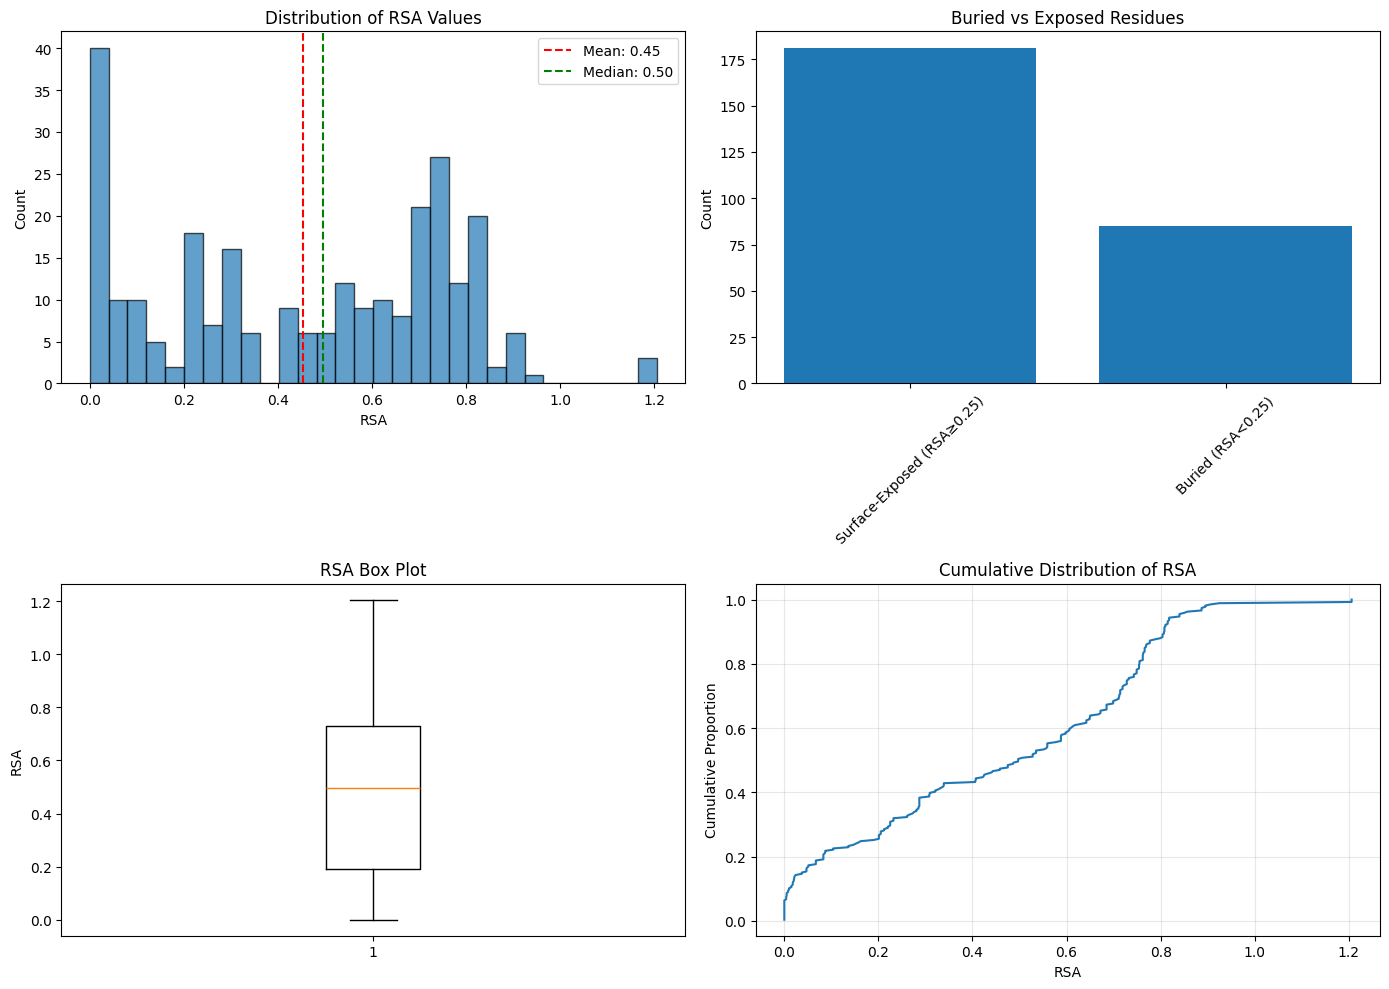


RSA Category Distribution:
RSA
0-0.1 (Very Buried)             41
0.1-0.2 (Buried)                 9
0.2-0.3 (Partially Exposed)     35
0.3-0.5 (Exposed)               32
0.5-1.0 (Highly Exposed)       129
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the missense mutations with RSA data
missense_rsa = pd.read_csv("missense_mutations_with_RSA.csv")

# Filter out rows without RSA data
missense_rsa_clean = missense_rsa[missense_rsa['RSA'].notna()].copy()

print(f"Missense mutations with RSA data: {len(missense_rsa_clean)}")
print(f"\nRSA Statistics:")
print(missense_rsa_clean['RSA'].describe())

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of RSA values
axes[0, 0].hist(missense_rsa_clean['RSA'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('RSA')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of RSA Values')
axes[0, 0].axvline(missense_rsa_clean['RSA'].mean(), color='red',
                   linestyle='--', label=f"Mean: {missense_rsa_clean['RSA'].mean():.2f}")
axes[0, 0].axvline(missense_rsa_clean['RSA'].median(), color='green',
                   linestyle='--', label=f"Median: {missense_rsa_clean['RSA'].median():.2f}")
axes[0, 0].legend()

# 2. Categorize RSA (Buried vs Exposed)
# RSA < 0.25 is buried, ≥ 0.25 is surface-exposed
missense_rsa_clean['Exposure'] = missense_rsa_clean['RSA'].apply(
    lambda x: 'Buried (RSA<0.25)' if x < 0.25 else 'Surface-Exposed (RSA≥0.25)'
)
exposure_counts = missense_rsa_clean['Exposure'].value_counts()
axes[0, 1].bar(exposure_counts.index, exposure_counts.values)
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Buried vs Exposed Residues')
axes[0, 1].tick_params(axis='x', rotation=45)

print(f"\n{exposure_counts}")

# 3. Box plot
axes[1, 0].boxplot(missense_rsa_clean['RSA'], vert=True)
axes[1, 0].set_ylabel('RSA')
axes[1, 0].set_title('RSA Box Plot')

# 4. Cumulative distribution
sorted_rsa = np.sort(missense_rsa_clean['RSA'])
cumulative = np.arange(1, len(sorted_rsa) + 1) / len(sorted_rsa)
axes[1, 1].plot(sorted_rsa, cumulative)
axes[1, 1].set_xlabel('RSA')
axes[1, 1].set_ylabel('Cumulative Proportion')
axes[1, 1].set_title('Cumulative Distribution of RSA')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional analysis: RSA bins
rsa_bins = pd.cut(missense_rsa_clean['RSA'],
                  bins=[0, 0.1, 0.2, 0.3, 0.5, 1.0],
                  labels=['0-0.1 (Very Buried)', '0.1-0.2 (Buried)',
                          '0.2-0.3 (Partially Exposed)', '0.3-0.5 (Exposed)',
                          '0.5-1.0 (Highly Exposed)'])

print(f"\nRSA Category Distribution:")
print(rsa_bins.value_counts().sort_index())

SECONDARY STRUCTURE ANALYSIS

Total missense mutations: 266

Mutations by secondary structure type:
  Loop: 151 (56.8%)
  Beta: 87 (32.7%)
  Alpha: 28 (10.5%)

--------------------------------------------------------------------------------
Mutations by specific secondary structure element:
--------------------------------------------------------------------------------
  Loop/Coil: 151 (56.8%)
  β8: 19 (7.1%)
  β3: 10 (3.8%)
  β6: 9 (3.4%)
  α1: 9 (3.4%)
  β12: 9 (3.4%)
  β7: 9 (3.4%)
  α2: 7 (2.6%)
  α3: 7 (2.6%)
  β9: 6 (2.3%)
  β4: 6 (2.3%)
  β2: 6 (2.3%)
  β1: 5 (1.9%)
  α4: 5 (1.9%)
  β11: 4 (1.5%)
  β5: 3 (1.1%)
  β10: 1 (0.4%)


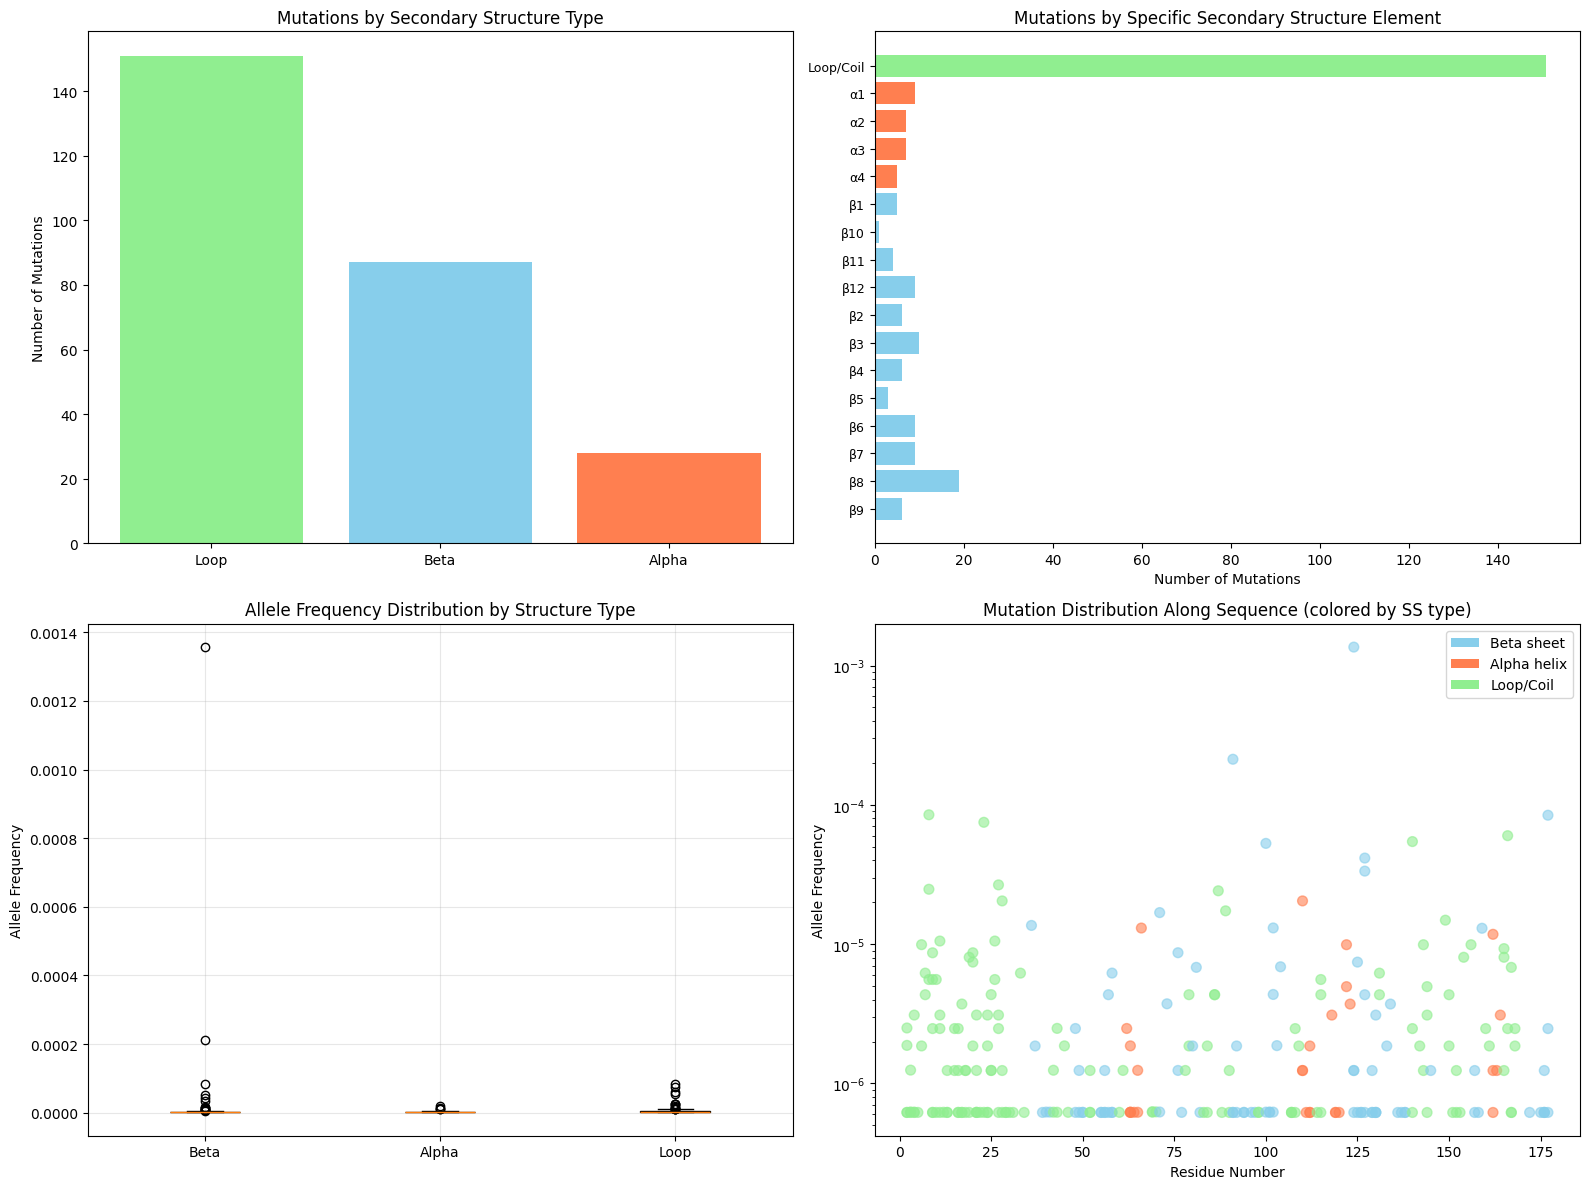


--------------------------------------------------------------------------------
ALLELE FREQUENCY STATISTICS BY STRUCTURE TYPE:
--------------------------------------------------------------------------------

Beta:
  Count: 87
  Mean AF: 0.000022
  Median AF: 0.000001
  Std Dev: 0.000147

Alpha:
  Count: 28
  Mean AF: 0.000003
  Median AF: 0.000001
  Std Dev: 0.000005

Loop:
  Count: 151
  Mean AF: 0.000005
  Median AF: 0.000001
  Std Dev: 0.000012

Results saved to: missense_with_secondary_structure.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the missense mutations with RSA data
missense_rsa = pd.read_csv("missense_mutations_with_RSA.csv")

# Define secondary structure elements
secondary_structures = {
    'β1': {'positions': range(35, 42), 'type': 'beta'},
    'β2': {'positions': range(47, 52), 'type': 'beta'},
    'β3': {'positions': range(54, 59), 'type': 'beta'},
    'β4': {'positions': range(71, 78), 'type': 'beta'},
    'β5': {'positions': range(80, 83), 'type': 'beta'},
    'β6': {'positions': range(91, 98), 'type': 'beta'},
    'β7': {'positions': range(100, 107), 'type': 'beta'},
    'β8': {'positions': range(124, 131), 'type': 'beta'},
    'β9': {'positions': range(133, 139), 'type': 'beta'},
    'β10': {'positions': range(145, 148), 'type': 'beta'},
    'β11': {'positions': range(157, 160), 'type': 'beta'},
    'β12': {'positions': range(171, 178), 'type': 'beta'},
    'α1': {'positions': range(62, 68), 'type': 'alpha'},
    'α2': {'positions': range(110, 113), 'type': 'alpha'},
    'α3': {'positions': range(117, 124), 'type': 'alpha'},
    'α4': {'positions': range(162, 165), 'type': 'alpha'}
}

# Assign secondary structure to each mutation
def assign_secondary_structure(res_num):
    if pd.isna(res_num):
        return 'Unknown', 'unknown'
    res_num = int(res_num)
    for ss_name, ss_info in secondary_structures.items():
        if res_num in ss_info['positions']:
            return ss_name, ss_info['type']
    return 'Loop/Coil', 'loop'

missense_rsa['SS_Element'] = missense_rsa['ResNum'].apply(lambda x: assign_secondary_structure(x)[0])
missense_rsa['SS_Type'] = missense_rsa['ResNum'].apply(lambda x: assign_secondary_structure(x)[1])

print("="*80)
print("SECONDARY STRUCTURE ANALYSIS")
print("="*80)

# Overall statistics
print(f"\nTotal missense mutations: {len(missense_rsa)}")

ss_counts = missense_rsa['SS_Type'].value_counts()
print(f"\nMutations by secondary structure type:")
for ss_type, count in ss_counts.items():
    percentage = (count / len(missense_rsa)) * 100
    print(f"  {ss_type.capitalize()}: {count} ({percentage:.1f}%)")

# Detailed breakdown by element
print(f"\n" + "-"*80)
print("Mutations by specific secondary structure element:")
print("-"*80)

element_counts = missense_rsa['SS_Element'].value_counts()
for element, count in element_counts.items():
    percentage = (count / len(missense_rsa)) * 100
    print(f"  {element}: {count} ({percentage:.1f}%)")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: By structure type (beta, alpha, loop)
ss_type_counts = missense_rsa['SS_Type'].value_counts()
colors_type = {'beta': 'skyblue', 'alpha': 'coral', 'loop': 'lightgreen', 'unknown': 'gray'}
ax_colors = [colors_type.get(ss, 'gray') for ss in ss_type_counts.index]

axes[0, 0].bar(range(len(ss_type_counts)), ss_type_counts.values, color=ax_colors)
axes[0, 0].set_xticks(range(len(ss_type_counts)))
axes[0, 0].set_xticklabels([x.capitalize() for x in ss_type_counts.index])
axes[0, 0].set_ylabel('Number of Mutations')
axes[0, 0].set_title('Mutations by Secondary Structure Type')

# Plot 2: By specific element
element_counts_sorted = element_counts.sort_index()
element_colors = ['skyblue' if 'β' in e else 'coral' if 'α' in e else 'lightgreen'
                  for e in element_counts_sorted.index]

axes[0, 1].barh(range(len(element_counts_sorted)), element_counts_sorted.values,
                color=element_colors)
axes[0, 1].set_yticks(range(len(element_counts_sorted)))
axes[0, 1].set_yticklabels(element_counts_sorted.index, fontsize=9)
axes[0, 1].set_xlabel('Number of Mutations')
axes[0, 1].set_title('Mutations by Specific Secondary Structure Element')
axes[0, 1].invert_yaxis()

# Plot 3: Allele frequency by structure type
ss_type_data = [missense_rsa[missense_rsa['SS_Type'] == ss_type]['Allele Frequency'].dropna()
                for ss_type in ['beta', 'alpha', 'loop'] if ss_type in ss_type_counts.index]
ss_type_labels = [ss_type.capitalize() for ss_type in ['beta', 'alpha', 'loop']
                  if ss_type in ss_type_counts.index]

bp = axes[1, 0].boxplot(ss_type_data, tick_labels=ss_type_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], [colors_type.get(ss, 'gray') for ss in ['beta', 'alpha', 'loop']]):
    patch.set_facecolor(color)
axes[1, 0].set_ylabel('Allele Frequency')
axes[1, 0].set_title('Allele Frequency Distribution by Structure Type')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Distribution along protein sequence
axes[1, 1].scatter(missense_rsa['ResNum'], missense_rsa['Allele Frequency'],
                   c=missense_rsa['SS_Type'].map({'beta': 'skyblue', 'alpha': 'coral',
                                                   'loop': 'lightgreen', 'unknown': 'gray'}),
                   alpha=0.6, s=50)
axes[1, 1].set_xlabel('Residue Number')
axes[1, 1].set_ylabel('Allele Frequency')
axes[1, 1].set_title('Mutation Distribution Along Sequence (colored by SS type)')
axes[1, 1].set_yscale('log')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='skyblue', label='Beta sheet'),
                   Patch(facecolor='coral', label='Alpha helix'),
                   Patch(facecolor='lightgreen', label='Loop/Coil')]
axes[1, 1].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Statistical comparison
print(f"\n" + "-"*80)
print("ALLELE FREQUENCY STATISTICS BY STRUCTURE TYPE:")
print("-"*80)

for ss_type in ['beta', 'alpha', 'loop']:
    if ss_type in missense_rsa['SS_Type'].values:
        ss_data = missense_rsa[missense_rsa['SS_Type'] == ss_type]['Allele Frequency']
        print(f"\n{ss_type.capitalize()}:")
        print(f"  Count: {len(ss_data)}")
        print(f"  Mean AF: {ss_data.mean():.6f}")
        print(f"  Median AF: {ss_data.median():.6f}")
        print(f"  Std Dev: {ss_data.std():.6f}")

# Save results
output_file = "missense_with_secondary_structure.csv"
missense_rsa.to_csv(output_file, index=False)
print(f"\nResults saved to: {output_file}")

PROTEIN-PROTEIN INTERACTION SITE ANALYSIS

Total missense mutations: 266
Mutations at PPI sites: 18
Percentage at PPI sites: 6.77%

--------------------------------------------------------------------------------
MISSENSE MUTATIONS AT PPI SITES:
--------------------------------------------------------------------------------
 ResNum HGVS Consequence Protein Consequence IL1R1_Partner                           Interaction_Type   RSA  Allele Frequency  Allele Count ClinVar Germline Classification
     36       p.Gln36Pro          p.Gln36Pro        Ser235                Side-Chain (Hydrogen Bonds) 0.285      1.363164e-05            22                             NaN
     41       p.Trp41Arg          p.Trp41Arg        Leu198          Side-Chain (Hydrophobic Contacts) 0.152      6.227736e-07             1                             NaN
     43       p.Val43Gly          p.Val43Gly        Arg160 Main-Chain (Receptor Side-Antagonist Main) 0.321      6.214832e-07             1                  

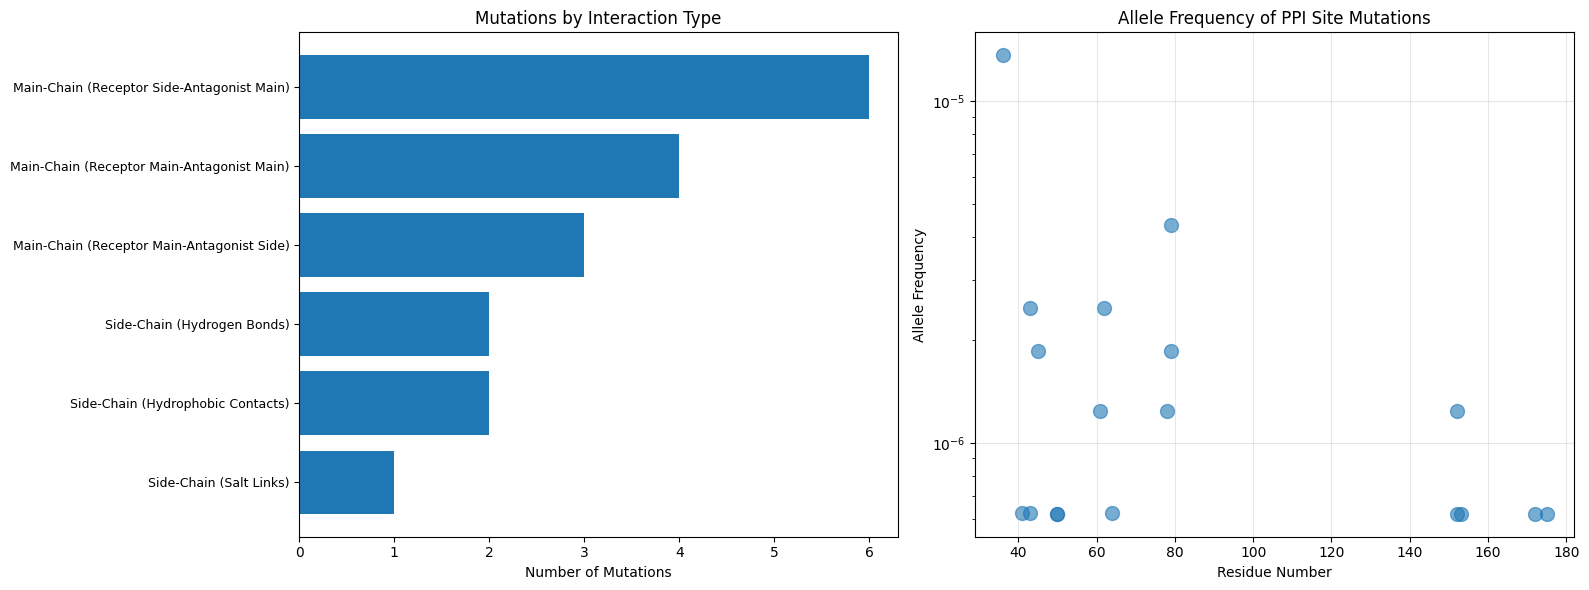


--------------------------------------------------------------------------------
STATISTICS:
--------------------------------------------------------------------------------
Mean allele frequency at PPI sites: 0.000002
Mean allele frequency overall: 0.000010

PPI site mutations saved to: ppi_site_mutations.csv

PPI SITE SUMMARY:
Total known PPI sites: 17
Sites with mutations: 14
Sites without mutations: 3


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the missense mutations with RSA data
missense_rsa = pd.read_csv("missense_mutations_with_RSA.csv")

# Define protein-protein interaction sites from IL-1R1
ppi_sites = {
    8: {'partner': 'Glu8', 'interaction': 'Side-Chain (Salt Links)'},
    268: {'partner': 'Arg268', 'interaction': 'Side-Chain (Salt Links)'},
    124: {'partner': 'Tyr124', 'interaction': 'Side-Chain (Hydrogen Bonds)'},
    235: {'partner': 'Ser235', 'interaction': 'Side-Chain (Hydrogen Bonds)'},
    10: {'partner': 'Ile10', 'interaction': 'Side-Chain (Hydrophobic Contacts)'},
    198: {'partner': 'Leu198', 'interaction': 'Side-Chain (Hydrophobic Contacts)'},
    113: {'partner': 'Pro113', 'interaction': 'Side-Chain (Hydrophobic Contacts)'},
    9: {'partner': 'Lys9', 'interaction': 'Main-Chain (Receptor Side-Antagonist Main)'},
    126: {'partner': 'Glu126', 'interaction': 'Main-Chain (Receptor Side-Antagonist Main)'},
    160: {'partner': 'Arg160', 'interaction': 'Main-Chain (Receptor Side-Antagonist Main)'},
    11: {'partner': 'Ile11', 'interaction': 'Main-Chain (Receptor Main-Antagonist Side)'},
    13: {'partner': 'Val13', 'interaction': 'Main-Chain (Receptor Main-Antagonist Side)'},
    106: {'partner': 'Ala106', 'interaction': 'Main-Chain (Receptor Main-Antagonist Side)'},
    111: {'partner': 'Lys111', 'interaction': 'Main-Chain (Receptor Main-Antagonist Side)'},
    119: {'partner': 'Gly119', 'interaction': 'Main-Chain (Receptor Main-Antagonist Side)'},
    107: {'partner': 'Ile107', 'interaction': 'Main-Chain (Receptor Main-Antagonist Main)'},
    296: {'partner': 'Asn296', 'interaction': 'Main-Chain (Receptor Main-Antagonist Main)'},
    297: {'partner': 'Thr297', 'interaction': 'Main-Chain (Receptor Main-Antagonist Main)'}
}

# Note: The table shows IL-1Ra residues interacting with IL-1R1
# We need to map the IL-1Ra residues (left column)
il1ra_ppi_sites = {
    51: {'partner': 'Arg51', 'il1r1_partner': 'Glu8', 'interaction': 'Side-Chain (Salt Links)'},
    175: {'partner': 'Glu175', 'il1r1_partner': 'Arg268', 'interaction': 'Side-Chain (Salt Links)'},
    153: {'partner': 'Asp153', 'il1r1_partner': 'Tyr124', 'interaction': 'Side-Chain (Hydrogen Bonds)'},
    36: {'partner': 'Gln36', 'il1r1_partner': 'Ser235', 'interaction': 'Side-Chain (Hydrogen Bonds)'},
    67: {'partner': 'Leu67', 'il1r1_partner': 'Ile10', 'interaction': 'Side-Chain (Hydrophobic Contacts)'},
    41: {'partner': 'Trp41', 'il1r1_partner': 'Leu198', 'interaction': 'Side-Chain (Hydrophobic Contacts)'},
    172: {'partner': 'Tyr172', 'il1r1_partner': 'Pro113', 'interaction': 'Side-Chain (Hydrophobic Contacts)'},
    50: {'partner': 'Leu50', 'il1r1_partner': 'Lys9', 'interaction': 'Main-Chain (Receptor Side-Antagonist Main)'},
    152: {'partner': 'Ala152', 'il1r1_partner': 'Glu126', 'interaction': 'Main-Chain (Receptor Side-Antagonist Main)'},
    59: {'partner': 'Tyr59', 'il1r1_partner': 'Tyr124', 'interaction': 'Main-Chain (Receptor Side-Antagonist Main)'},
    43: {'partner': 'Val43', 'il1r1_partner': 'Arg160', 'interaction': 'Main-Chain (Receptor Side-Antagonist Main)'},
    64: {'partner': 'Asn64', 'il1r1_partner': 'Ile11', 'interaction': 'Main-Chain (Receptor Main-Antagonist Side)'},
    61: {'partner': 'Gln61', 'il1r1_partner': 'Val13', 'interaction': 'Main-Chain (Receptor Main-Antagonist Side)'},
    45: {'partner': 'Gln45', 'il1r1_partner': 'Lys111', 'interaction': 'Main-Chain (Receptor Main-Antagonist Side)'},
    62: {'partner': 'Gly62', 'il1r1_partner': 'Ile107', 'interaction': 'Main-Chain (Receptor Main-Antagonist Main)'},
    78: {'partner': 'Pro78', 'il1r1_partner': 'Asn296', 'interaction': 'Main-Chain (Receptor Main-Antagonist Main)'},
    79: {'partner': 'His79', 'il1r1_partner': 'Thr297', 'interaction': 'Main-Chain (Receptor Main-Antagonist Main)'}
}

# Note: Gln61 appears twice with different partners (Val13 and Ala106), and Gln45 with Lys111 and Gly119

print("="*80)
print("PROTEIN-PROTEIN INTERACTION SITE ANALYSIS")
print("="*80)

# Check which missense mutations affect PPI sites
missense_rsa['Is_PPI_Site'] = missense_rsa['ResNum'].isin(il1ra_ppi_sites.keys())
ppi_mutations = missense_rsa[missense_rsa['Is_PPI_Site'] == True].copy()

print(f"\nTotal missense mutations: {len(missense_rsa)}")
print(f"Mutations at PPI sites: {len(ppi_mutations)}")
print(f"Percentage at PPI sites: {len(ppi_mutations)/len(missense_rsa)*100:.2f}%")

# Add interaction details
def get_interaction_info(res_num):
    if res_num in il1ra_ppi_sites:
        return il1ra_ppi_sites[res_num]['interaction']
    return None

def get_partner_info(res_num):
    if res_num in il1ra_ppi_sites:
        return il1ra_ppi_sites[res_num]['il1r1_partner']
    return None

ppi_mutations['Interaction_Type'] = ppi_mutations['ResNum'].apply(get_interaction_info)
ppi_mutations['IL1R1_Partner'] = ppi_mutations['ResNum'].apply(get_partner_info)

if len(ppi_mutations) > 0:
    print("\n" + "-"*80)
    print("MISSENSE MUTATIONS AT PPI SITES:")
    print("-"*80)

    display_cols = ['ResNum', 'HGVS Consequence', 'Protein Consequence',
                    'IL1R1_Partner', 'Interaction_Type', 'RSA', 'Allele Frequency',
                    'Allele Count', 'ClinVar Germline Classification']

    ppi_display = ppi_mutations[display_cols].sort_values('ResNum')
    print(ppi_display.to_string(index=False))

    # Visualize interaction types
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Count by interaction type
    interaction_counts = ppi_mutations['Interaction_Type'].value_counts()
    axes[0].barh(range(len(interaction_counts)), interaction_counts.values)
    axes[0].set_yticks(range(len(interaction_counts)))
    axes[0].set_yticklabels(interaction_counts.index, fontsize=9)
    axes[0].set_xlabel('Number of Mutations')
    axes[0].set_title('Mutations by Interaction Type')
    axes[0].invert_yaxis()

    # Plot 2: Allele frequency at PPI sites
    ppi_with_af = ppi_mutations[ppi_mutations['Allele Frequency'] > 0]
    if len(ppi_with_af) > 0:
        axes[1].scatter(ppi_with_af['ResNum'], ppi_with_af['Allele Frequency'],
                       alpha=0.6, s=100)
        axes[1].set_xlabel('Residue Number')
        axes[1].set_ylabel('Allele Frequency')
        axes[1].set_title('Allele Frequency of PPI Site Mutations')
        axes[1].set_yscale('log')
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Statistics
    print("\n" + "-"*80)
    print("STATISTICS:")
    print("-"*80)
    print(f"Mean allele frequency at PPI sites: {ppi_mutations['Allele Frequency'].mean():.6f}")
    print(f"Mean allele frequency overall: {missense_rsa['Allele Frequency'].mean():.6f}")

    # Save to file
    output_file = "ppi_site_mutations.csv"
    ppi_mutations.to_csv(output_file, index=False)
    print(f"\nPPI site mutations saved to: {output_file}")

else:
    print("\nNo missense mutations found at known PPI sites!")

# Summary of PPI sites
print("\n" + "="*80)
print("PPI SITE SUMMARY:")
print("="*80)
print(f"Total known PPI sites: {len(il1ra_ppi_sites)}")
print(f"Sites with mutations: {ppi_mutations['ResNum'].nunique()}")
print(f"Sites without mutations: {len(il1ra_ppi_sites) - ppi_mutations['ResNum'].nunique()}")